In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

In [2]:
# Create the data from the table
data = {
    'Protein': ['PreQ1', 'PreQ1', 'SAM_II', 'SAM_II', 'TPP', 'TPP', 'ZTP', 'ZTP'],
    'PDB': ['3FU2', '3FU2', '2QWY', '2QWY', '2GDI', '2GDI', '5BTP', '5BTP'],
    'Method': ['SMARTBind', 'RNAmigos2', 'SMARTBind', 'RNAmigos2', 'SMARTBind', 'RNAmigos2', 'SMARTBind', 'RNAmigos2'],
    'Top_500': [11.98, 0, 0, 0, 0, 0, 0, 0],
    'Top_1000': [5.99, 0, 0, 5.08, 0, 12.27, 5.85, 0],
    'Top_5000': [1.2, 2.4, 1.02, 8.12, 1.23, 6.13, 3.51, 1.17],
    'Top_10000': [1.8, 2.4, 1.02, 5.58, 0.61, 3.68, 1.75, 0.58]
}

df = pd.DataFrame(data)
print(df)

  Protein   PDB     Method  Top_500  Top_1000  Top_5000  Top_10000
0   PreQ1  3FU2  SMARTBind    11.98      5.99      1.20       1.80
1   PreQ1  3FU2  RNAmigos2     0.00      0.00      2.40       2.40
2  SAM_II  2QWY  SMARTBind     0.00      0.00      1.02       1.02
3  SAM_II  2QWY  RNAmigos2     0.00      5.08      8.12       5.58
4     TPP  2GDI  SMARTBind     0.00      0.00      1.23       0.61
5     TPP  2GDI  RNAmigos2     0.00     12.27      6.13       3.68
6     ZTP  5BTP  SMARTBind     0.00      5.85      3.51       1.75
7     ZTP  5BTP  RNAmigos2     0.00      0.00      1.17       0.58


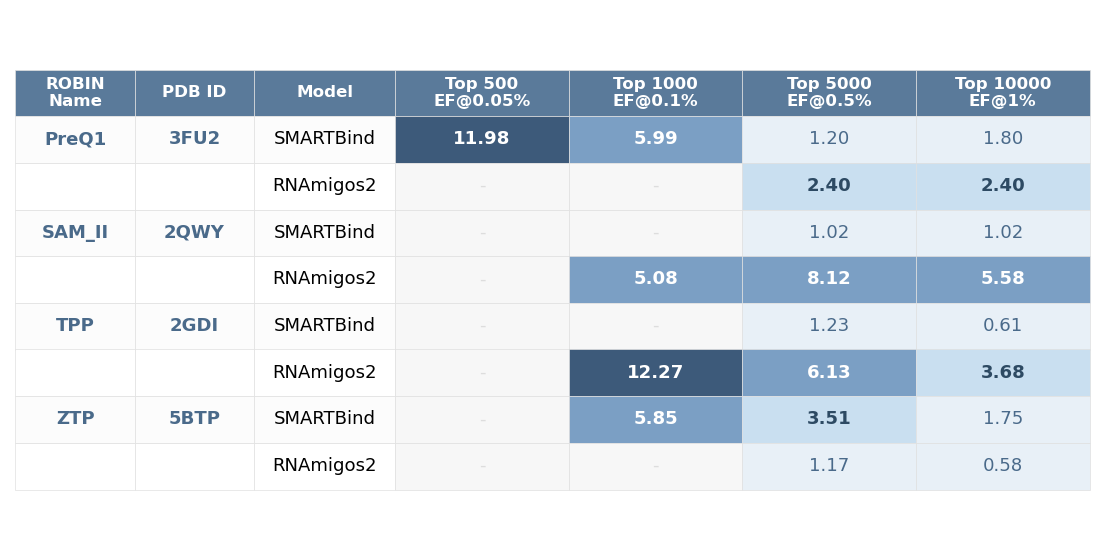


✓ Figure saved as 'ef_comparison_table.png'


In [ ]:
fig, ax = plt.subplots(figsize=(14, 7))
ax.axis('tight')
ax.axis('off')

# Prepare table data with better formatting
table_data = []
for protein in df['Protein'].unique():
    pdb = df[df['Protein'] == protein]['PDB'].iloc[0]
    sb_row = df[(df['Protein'] == protein) & (df['Method'] == 'SMARTBind')][['Top_500', 'Top_1000', 'Top_5000', 'Top_10000']].values[0]
    rna_row = df[(df['Protein'] == protein) & (df['Method'] == 'RNAmigos2')][['Top_500', 'Top_1000', 'Top_5000', 'Top_10000']].values[0]
    
    table_data.append([protein, pdb, 'SMARTBind'] + [f'{v:.2f}' if v > 0 else '-' for v in sb_row])
    table_data.append(['', '', 'RNAmigos2'] + [f'{v:.2f}' if v > 0 else '-' for v in rna_row])

# Create table with adjusted column widths
columns = ['ROBIN\nName', 'PDB ID', 'Model', 'Top 500\nEF@0.05%', 'Top 1000\nEF@0.1%', 'Top 5000\nEF@0.5%', 'Top 10000\nEF@1%']
table = ax.table(cellText=table_data, colLabels=columns, cellLoc='center', loc='center',
                colWidths=[0.11, 0.11, 0.13, 0.16, 0.16, 0.16, 0.16])

table.auto_set_font_size(False)
table.set_fontsize(13)
table.scale(1, 2.8)

# Scientific publication color palette - Blue gradient
light_blue = '#e8f0f7'        # Very light blue
medium_light_blue = '#c9dff0'  # Light blue-gray
medium_blue = '#7B9FC4'        # Soft blue
dark_blue = '#3d5a7a'          # Deep blue for high values

# Color cells based on values with blue gradient
for i in range(len(table_data)):
    row_idx = i + 1
    
    # Alternate row background for better readability
    row_bg = '#fcfcfc' if i % 2 == 0 else 'white'
    for j in range(3):
        table[(row_idx, j)].set_facecolor(row_bg)
    
    # Color value columns
    for j in range(3, 7):
        cell = table[(row_idx, j)]
        try:
            value = float(table_data[i][j])
            if value == 0:
                cell.set_facecolor('#f7f7f7')
                cell.set_text_props(color='#aaaaaa', style='italic')
            elif value < 2:
                cell.set_facecolor(light_blue)  # Very light blue
                cell.set_text_props(color='#4a6a8a', weight='normal')
            elif value < 5:
                cell.set_facecolor(medium_light_blue)  # Light blue-gray
                cell.set_text_props(color='#2d4a63', weight='bold')
            elif value < 10:
                cell.set_facecolor(medium_blue)  # Medium blue
                cell.set_text_props(color='white', weight='bold')
            else:
                cell.set_facecolor(dark_blue)  # Deep blue for high values
                cell.set_text_props(color='white', weight='bold')
        except:
            cell.set_facecolor('#f7f7f7')
            cell.set_text_props(color='#dddddd')

for j in range(len(columns)):
    cell = table[(0, j)]
    cell.set_facecolor('#5a7a9a')  # Muted blue-gray
    cell.set_text_props(weight='bold', color='white', fontsize=12)
    cell.set_edgecolor('white')
    cell.set_linewidth(1.5)

for i in range(0, len(table_data), 2):
    table[(i+1, 0)].set_text_props(weight='bold', color='#4a6a8a')
    table[(i+1, 1)].set_text_props(weight='bold', color='#4a6a8a')

for key, cell in table.get_celld().items():
    cell.set_edgecolor('#e0e0e0')
    cell.set_linewidth(0.5)

# plt.savefig('ef_comparison_table.png', dpi=600, bbox_inches='tight', facecolor='white')
plt.show()